# Objetivo: que toda la difusion vaya junta, y que cambiando las clases cambiemos soii es minst o de audios o stable

In [ ]:
%run init_notebook.py

import torch.nn as nn
from torchvision.datasets import FashionMNIST, QMNIST, KMNIST
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import time
import json

import torchaudio.transforms as T
from src.dataset import NSynth, LatentDataset, LatentNSynth
import torch
from src.diffusion import *
from src.utils.models import adjust_shape, compute_magnitude_and_phase, compute_magnitude_and_phase_sin_cos
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

root = r"C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\diffusion"
paths = {
    'minst' : {
        'root': root + r"\minst",
        'model': root + r"\minst\model.pth",
        'object': root + r"\minst\object.pth",
        'scheduler': root + r"\minst\scheduler.pth",
        'checkpoint': root + r"\minst\checkpoint.pth",
        'dataset' : r"C:\Users\Articuno\Desktop\TFG-info\data\mnist"
    },
    'audio' : {
        'root': root + r"\audio",
        'model': root + r"\audio\model.pth",
        'object': root + r"\audio\object.pth",
        'scheduler': root + r"\audio\scheduler.pth",
        'checkpoint': root + r"\audio\checkpoint.pth"
    },
    'stable' : {
        'root': root + r"\stable",
        'model': root + r"\stable\model.pth",
        'object': root + r"\stable\object.pth",
        'scheduler': root + r"\stable\scheduler.pth",
        'checkpoint': root + r"\stable\checkpoint.pth",
    }
}

In [23]:
def save_checkpoint(model, optimizer, epoch, loss, path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }, path)

def load_checkpoint(model, optimizer, path):
    checkpoint = torch.load(path, map_location='cpu')  # o 'cuda' si usas GPU
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    
    return model, optimizer, epoch, loss

def train(
    model, 
    scheduler,
    transform_data=None,
    epochs=100, 
    batch_size=16, 
    lr=1e-3, 
    modality='audio',
    dataset=NSynth('training'), 
    verbose=False,
    verbose_batchs=0,
):
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    diffuser = Diffuser(model, scheduler).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)    
    scaler = torch.cuda.amp.GradScaler()
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)


    mse_loss = nn.MSELoss()
    best_loss = 1
    losses = []
    
    num_timesteps = scheduler.alpha_bar.shape[0]

        
    for epoch in range(epochs):
        start_time = time.time() 
        _d_batch_index = 0
        epoch_loss = 0
        for x in train_loader:
            _d_batch_index += 1
            # wave = wave.to(device)
            # x = stft_transform(wave)
            if transform_data is not None:
                x = transform_data(x)
            x = x.to(device)                
            batch_size = x.size(0)
            t = torch.randint(0, num_timesteps, (batch_size,), device=device, dtype=torch.long)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast(dtype=torch.bfloat16): # OPTIMIZACION FLOAT 32
                # print(f"mag: {mag.shape}, sin: {sin.shape}, cos: {cos.shape}, x: {x.shape}")
                z, e = diffuser(x, t)
                e_pred = model(z, t)
                if e_pred.shape != e.shape: # TODO borrar esto es debug
                    print('error en los tamaños')

                loss = mse_loss(e_pred, e)
                epoch_loss += loss.item()

            scaler.scale(loss).backward() # TODO no se si la funcion de loss es la mas optima para el caso
            scaler.step(optimizer)

            scaler.update()
            
            if verbose_batchs != 0:
                if _d_batch_index % verbose_batchs == 0:
                    _t = time.time() - start_time
                    print(f'time in {_d_batch_index} batchs: {_t:.5f} \t| avg time per batch: {_t/_d_batch_index:.5f} \t| avg loss: {epoch_loss/_d_batch_index:.5f}')

        losses.append(epoch_loss/_d_batch_index)
        lr_scheduler.step() # LEARNING SCHEDULER

            
        if verbose:
            _t = time.time() - start_time
            print(f"Epoch {epoch}, Loss: {loss.item()}, time: {time.time() - start_time}, avg x time: {_t/(batch_size*_d_batch_index)}")
            
        if loss.item() < best_loss:
            best_loss = loss.item()
            
            if modality:
                save_checkpoint(model, optimizer, epoch, loss.item(), paths[modality]['checkpoint'])
            
    
    # AL FINALIZAR EL ENTRENAMIENTO, GUARDAMOS EL MODELO Y EL SCHEDULER
    if modality:
        torch.save(model.state_dict(), paths[modality]['model'])
        torch.save(scheduler.state_dict(), paths[modality]['scheduler'])
        torch.save(model, paths[modality]['object'])
        
    print("Training completed., best loss:", best_loss)
    
    return model, scheduler, losses
    

## MINST

In [24]:
def MINST_transform(x):
    img, _ = x
    return img

In [25]:
def setup_minst_model(timesteps=1000, channels=32, norm_groups=6, emb_dim=128):
    ## Image Size
    # input_height = 28
    # input_width = 28
    # input_size = (input_height, input_width)

    down_layers = [  
        DummyLayer(channels,    channels*2,  norm_groups, emb_dim, skip=True, stride=1).to(device),  # skip: c canales
        DummyLayer(channels*2,  channels*4,  norm_groups, emb_dim, skip=False, stride=1).to(device),  # skip: c*2 canales
        DummyLayer(channels*4,  channels*8,  norm_groups, emb_dim, skip=False, stride=1).to(device),  # skip: c*4 canales
        # DummyLayer(c*8,  c*16, norm_groups, emb_dim, skip=True, stride=2).to(device),  # skip: c*8 canales
    ]

    bottleneck = DummyLayer(channels*8, channels*8, norm_groups, emb_dim).to(device)

    up_layers = [
        # DummyLayer(c*16 + c*8,  c*8, norm_groups, emb_dim, stride=-2).to(device),
        DummyLayer(channels*8,  channels*4, norm_groups, emb_dim, stride=-1).to(device),
        DummyLayer(channels*4,  channels*2, norm_groups, emb_dim, stride=-1).to(device),
        DummyLayer(channels*2 + channels,    channels,   norm_groups, emb_dim, stride=-1).to(device),
    ]

    # EMBEDDER
    embedder = Embedder(num_timesteps=timesteps, embed_dim=emb_dim).to(device)

    # SCHEDULER
    scheduler = Scheduler(num_timesteps=timesteps).to(device)

    # MODEL
    model = DiffusionModel(
        layer_channels=(channels, channels),
        norm_groups=norm_groups,
        up_layers=up_layers,
        down_layers=down_layers,
        bottleneck=bottleneck,
        embedder=embedder, 
        input_channels=1,
        output_channels=1,
    ).to(device)
    
    return model, scheduler, MINST_transform

def train_MINST(
    model,
    scheduler,
    transform_data=None,
    epochs=10, 
    batch_size=2048, 
    learning_rate=1e-4, 
    ):

    # %%time
    model, scheduler, losses = train(
        model, 
        scheduler,
        transform_data=transform_data,
        epochs=epochs,
        batch_size=batch_size, 
        lr=learning_rate, 
        modality='minst',
        dataset= QMNIST(root=paths['minst']['dataset'], train=True,  download=True, transform=ToTensor()),
        verbose=True,
        verbose_batchs=0,
    )
    plt.plot(losses)
    print(f'learning_rate: {learning_rate}')
    
    return model, scheduler, losses


## AUDIO

In [26]:
class AudioPipeline:
    def __init__(self, stft_transform):
        self.stft_transform = stft_transform

def pipeline_audio(self, x):
    wave, _, _, _ = x # solo nos quedamos con la onda, el resto no nos interesa
    stft_spec = self.stft_transform(wave)
    log_mag, sin, cos = compute_magnitude_and_phase_sin_cos(stft_spec) ## SINCOS
    x = torch.cat([log_mag, sin, cos], dim=1).to(device)  ## SINCOS

In [27]:
def setup_audio_model(timesteps=1000, channels=32, norm_groups=6, emb_dim=128):
    ''' Devuelve el modelo de audio listo para entrenar'''
    
    sample_rate = 16000
    n_fft = 1500 # DISMINUIR TAMAÑO PARA OPTIMIZAR
    hop_length = 250
    win_length = n_fft
    
    # Data pipeline
    stft_transform = T.Spectrogram(
        n_fft=n_fft, win_length=win_length, hop_length=hop_length,
        power=None, onesided=False, center=False
    ).to(device)
    transform_audio = AudioPipeline(stft_transform)
    
    # Layers
    down_layers = [  
        DummyLayer(channels,    channels*2,  norm_groups, emb_dim, skip=True, stride=1).to(device),  # skip: c canales
        DummyLayer(channels*2,  channels*4,  norm_groups, emb_dim, skip=True, stride=1).to(device),  # skip: c*2 canales
    ]

    bottleneck = DummyLayer(channels*4, channels*4, norm_groups, emb_dim).to(device)

    up_layers = [ # TODO Podria hacer esto con stride = -2? o coger y hacer que si el stride es negativo, aumente manualmente 
        DummyLayer(channels*4 + channels*4, channels*2, norm_groups, emb_dim, stride=1).to(device),
        DummyLayer(channels*2 + channels*2, channels, norm_groups, emb_dim, stride=1).to(device),
    ]

    # Embedder
    embedder = Embedder(num_timesteps=timesteps, embed_dim=emb_dim).to(device)

    # scheduler
    scheduler = Scheduler(num_timesteps=timesteps).to(device)

    # model
    model = DiffusionModel(
        layer_channels=(channels, channels), # Por ahora los canales de entrada y salida son los mismos
        norm_groups=norm_groups,
        up_layers=up_layers,
        down_layers=down_layers,
        bottleneck=bottleneck,
        embedder=embedder, 
        input_channels=3, ##SINCOS
        output_channels=3, ##SINCOS
    ).to(device)
    
    return model, scheduler, transform_audio.stft_transform

def train_audio(
    model,
    scheduler,
    transform_data=None,
    epochs=10, 
    batch_size=128, 
    learning_rate=1e-4, 
    ):
    
    model, scheduler, losses = train(
        model, 
        scheduler,
        transform_data=transform_data,
        epochs=epochs,
        batch_size=batch_size, 
        lr=learning_rate, 
        modality='audio',
        dataset=NSynth('training'),
        verbose=True,
        verbose_batchs=100,
    )
    plt.plot(losses)
    print(f'learning_rate: {learning_rate}')
    return model, scheduler, losses

# LATENT SPACE
Entrenamos un modelo de difusión en el espacio latente de un VAE

In [ ]:
def latent_pipeline(x): # Creo que no hace nada
    lat, _ = x
    return lat

In [ ]:
def setup_latent_model(timesteps=1000, channels=32, norm_groups=6, emb_dim=128):
    ''' Devuelve el modelo de audio listo para entrenar'''
       
    # Layers
    down_layers = [  
        DummyLayer(channels,    channels*2,  norm_groups, emb_dim, skip=True, stride=1).to(device),  # skip: c canales
        DummyLayer(channels*2,  channels*4,  norm_groups, emb_dim, skip=True, stride=1).to(device),  # skip: c*2 canales
    ]

    bottleneck = DummyLayer(channels*4, channels*4, norm_groups, emb_dim).to(device)

    up_layers = [ # TODO Podria hacer esto con stride = -2? o coger y hacer que si el stride es negativo, aumente manualmente 
        DummyLayer(channels*4 + channels*4, channels*2, norm_groups, emb_dim, stride=1).to(device),
        DummyLayer(channels*2 + channels*2, channels, norm_groups, emb_dim, stride=1).to(device),
    ]

    # Embedder
    embedder = Embedder(num_timesteps=timesteps, embed_dim=emb_dim).to(device)

    # scheduler
    scheduler = Scheduler(num_timesteps=timesteps).to(device)

    # model
    model = DiffusionModel(
        layer_channels=(channels, channels), # Por ahora los canales de entrada y salida son los mismos
        norm_groups=norm_groups,
        up_layers=up_layers,
        down_layers=down_layers,
        bottleneck=bottleneck,
        embedder=embedder, 
        input_channels=3, ##SINCOS
        output_channels=3, ##SINCOS
    ).to(device)
    
    return model, scheduler, latent_pipeline

def train_latent(
    model,
    scheduler,
    transform_data=None,
    epochs=10, 
    batch_size=128, 
    learning_rate=1e-4, 
    ):
    
    model, scheduler, losses = train(
        model, 
        scheduler,
        transform_data=transform_data,
        epochs=epochs,
        batch_size=batch_size, 
        lr=learning_rate, 
        modality='audio',
        dataset=LatentDataset(rf"{paths['stable']['root']}/dataset/"),
        verbose=True,
        verbose_batchs=100,
    )
    plt.plot(losses)
    print(f'learning_rate: {learning_rate}')
    return model, scheduler, losses

# TRAININGS

Epoch 0, Loss: 0.09361835569143295, time: 75.1702971458435, avg x time: 0.0033316585189061805
Epoch 1, Loss: 0.07554049044847488, time: 75.96587610244751, avg x time: 0.0033669228355089824
Epoch 2, Loss: 0.07639837265014648, time: 76.65668368339539, avg x time: 0.0033975675807777026
Epoch 3, Loss: 0.06638017296791077, time: 76.44975256919861, avg x time: 0.0033883954827667127
Epoch 4, Loss: 0.06273481994867325, time: 76.77781891822815, avg x time: 0.003402961103628713
Epoch 5, Loss: 0.05258079245686531, time: 76.99220180511475, avg x time: 0.0034124611222997626
Epoch 6, Loss: 0.054813966155052185, time: 74.42412686347961, avg x time: 0.003298548138733451
Epoch 7, Loss: 0.04974093288183212, time: 76.66703796386719, avg x time: 0.003397979476350419
Epoch 8, Loss: 0.051625657826662064, time: 76.3855562210083, avg x time: 0.003385506010224633
Epoch 9, Loss: 0.055243972688913345, time: 76.43156027793884, avg x time: 0.003387634371612089
Epoch 10, Loss: 0.04854768514633179, time: 76.55224823

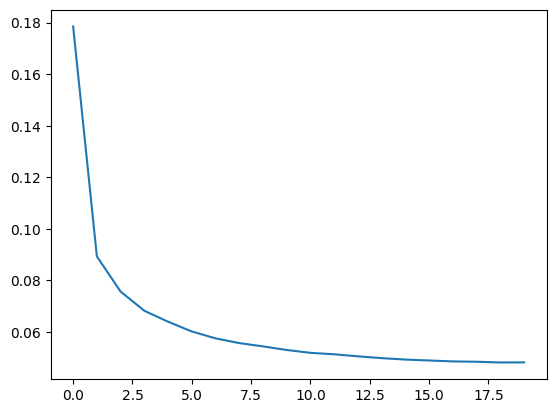

In [28]:
''' 
ENTRENAMIENTO DEL MODELO MINST
    se pueden configurar más elementos directamente en setup_minst_model 

'''
model, scheduler, trans = setup_minst_model(
    timesteps=300, # numero de pasos de quitar ruido
    channels=64,
    norm_groups=8,
    emb_dim=128
)
model, scheduler, losses = train_MINST(
    model=model,
    scheduler=scheduler,
    transform_data=trans,
    epochs=20,
    batch_size=2048//8,
    learning_rate=1e-4
)

In [29]:
# TODO 
# despues de setup_minst_model, hacer otra funcion que cargue el modelo y el scheduler de la memoria
# añadir validacion al entrenamiento
# guardar el lr scheduler
# añadir el stable
# añadir para mostrar imagenes y samplear y eso

# MODEL FROM MEM

In [ ]:
''' 
ENTRENAMIENTO DEL MODELO MINST
    se pueden configurar más elementos directamente en setup_minst_model 

'''
TRAIN = False

model, scheduler, trans = setup_minst_model(
    timesteps=300, # Tiene que ser el mismo que la que tuviera el modelo
    channels=64,
    norm_groups=8,
    emb_dim=128
)

if TRAIN:
    model, scheduler, losses = train_MINST(
        model=model,
        scheduler=scheduler,
        transform_data=trans,
        epochs=20,
        batch_size=2048//8,
        learning_rate=1e-4
    )
else:
    # model = torch.load(paths['minst']['object'])
    model.state_dict(torch.load(paths['minst']['model']))
    scheduler.load_state_dict(torch.load(paths['minst']['scheduler']))


In [ ]:
''' 
ENTRENAMIENTO DEL MODELO MINST
    se pueden configurar más elementos directamente en setup_minst_model 

'''
TRAIN = True

model, scheduler, trans = setup_audio_model(
    timesteps=300, # Tiene que ser el mismo que la que tuviera el modelo
    channels=64,
    norm_groups=8,
    emb_dim=128
)

if TRAIN:
    model, scheduler, losses = train_audio(
        model=model,
        scheduler=scheduler,
        transform_data=trans,
        epochs=20,
        batch_size=2048//8,
        learning_rate=1e-4
    )
else:
    # model = torch.load(paths['minst']['object'])
    model.state_dict(torch.load(paths['minst']['model']))
    scheduler.load_state_dict(torch.load(paths['minst']['scheduler']))


# SAMPLING

In [ ]:
def sample_raw_img(model, scheduler, image_size=(1, 28, 28), num_images=1):
    model.eval() # NS
    # with torch.no_grad():
    
    x = torch.randn(num_images, *image_size, device=device) # imagen de ruidio inicial
    T = scheduler.alpha_bar.shape[0]
    
    betas = scheduler.beta
    alphas = scheduler.alpha
    alpha_bars = scheduler.alpha_bar
    with torch.no_grad():

        for t in reversed(range(T)):
            t_batch = torch.full((num_images,), t, device=device, dtype=torch.long)

            # predicción de ruido
            e_pred = model(x, t_batch)
            
            beta_t = betas[t]
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]
            
            # beta_t = beta_t.view(1,1,1,1)
            # alpha_t = alpha_t.view(1,1,1,1)
            # alpha_bar_t = alpha_bar_t.view(1,1,1,1)


            # Coeficientes DDPM
            coef1 = 1 / torch.sqrt(alpha_t)
            coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)

            mu = coef1 * (x - coef2 * e_pred)

            if t > 0:
                noise = torch.randn_like(x)
                sigma_t = torch.sqrt(beta_t)
                x = mu + sigma_t * noise
            else:
                x = mu

        x = x.clamp(0, 1).cpu()
        
    return x

def denoise_img(model, scheduler, noisy_img, num_steps=300, step_imgs=10):
    model.eval()
    xs = []
    x = noisy_img.to(device)
    T = scheduler.alpha_bar.shape[0]
    
    betas = scheduler.beta
    alphas = scheduler.alpha
    alpha_bars = scheduler.alpha_bar
    
    with torch.no_grad():
        for t in reversed(range(T)):
            t_batch = torch.full((x.size(0),), t, device=device, dtype=torch.long)

            e_pred = model(x, t_batch)
            
            beta_t = betas[t]
            alpha_t = alphas[t]
            alpha_bar_t = alpha_bars[t]

            coef1 = 1 / torch.sqrt(alpha_t)
            coef2 = beta_t / torch.sqrt(1 - alpha_bar_t)

            mu = coef1 * (x - coef2 * e_pred)

            if t > 0:
                noise = torch.randn_like(x)
                sigma_t = torch.sqrt(beta_t)
                x = mu + sigma_t * noise
            else:
                x = mu
                
            if t % (T // step_imgs) == 0:
                xs.append(x.clamp(0, 1).cpu())

        x = x.clamp(0, 1).cpu()
        
    return x, xs
    
def show_imgs(xs, cols=5):
    rows = math.ceil(len(xs) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten()

    for i in range(len(xs)):
        axes[i].imshow(xs[i][0].detach().cpu().numpy(), cmap='gray')
        axes[i].axis('off')

    # Ocultar ejes sobrantes si n no es múltiplo de cols
    for j in range(len(xs), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

ver el proceso de sampling

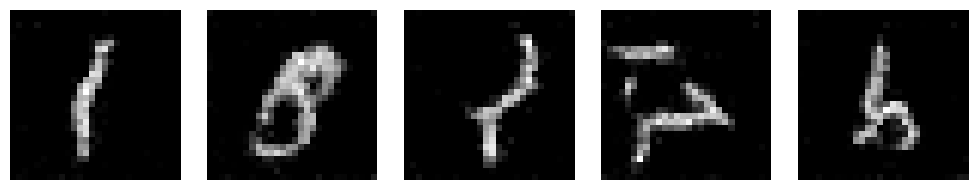

In [ ]:
# MNIST
xs = sample_raw_img(model, scheduler, image_size=(1, 28, 28), num_images=5)
show_imgs(xs)

ver el proceso de denoising paso a paso

In [ ]:
x = torch.randn(1, 1, 28, 28) # imagen de ruido inicial
x, xs = denoise_img(model, scheduler, x, num_steps=300, step_imgs=10)
show_imgs(xs)